In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, fbeta_score, 
                             precision_score, recall_score, classification_report,
                             confusion_matrix, roc_curve)
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('../data/processed/flights_engineered.csv')

cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
num_features = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'DISTANCE',
    'SCHED_DEP_HOUR', 
    'IS_PEAK_SEASON',
    'IS_EARLY_MORNING',     # strong negative signal
    'CARRIER_DELAY_RATE', 
    'ORIGIN_MONTHLY_DELAY_RATE', 
    'ROUTE_DELAY_RATE'
]
target = 'IS_DELAYED'

print(f"loaded: {df.shape}")

loaded: (490984, 40)


In [2]:
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
df = df.sort_values('DATE').reset_index(drop=True)

X = df[cat_features + num_features]
y = df[target]

n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test = X.iloc[val_end:], y.iloc[val_end:]

print(f"train: {X_train.shape}, delay rate: {y_train.mean():.3f}")
print(f"val:   {X_val.shape}, delay rate: {y_val.mean():.3f}")
print(f"test:  {X_test.shape}, delay rate: {y_test.mean():.3f}")
print("split done")

train: (294590, 13), delay rate: 0.195
val:   (98197, 13), delay rate: 0.140
test:  (98197, 13), delay rate: 0.163
split done


In [3]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_features)
])

def make_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

print("preprocessor ready")

preprocessor ready


In [4]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'DecisionTree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=10),
    'RandomForest': RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    # 'KNN': KNeighborsClassifier(n_neighbors=50, n_jobs=-1),  
    # 'SVM': SVC(probability=True, class_weight='balanced', random_state=42), 
    'XGBoost': XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
}

results = []

for name, model in models.items():
    print(f"\n{'='*40}")
    print(f"training {name}...")
    
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)
    
    
    y_pred = pipe.predict(X_val)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    
    auc = roc_auc_score(y_val, y_prob)
    f1 = f1_score(y_val, y_pred)
    f2 = fbeta_score(y_val, y_pred, beta=2)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    
    results.append({'Model': name, 'AUC': auc, 'F1': f1, 'F2': f2, 'Precision': prec, 'Recall': rec})
    
    print(f"AUC: {auc:.4f} | F1: {f1:.4f} | F2: {f2:.4f} | P: {prec:.4f} | R: {rec:.4f}")

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)
print("\n" + "="*60)
print(results_df.to_string(index=False))


training LogisticRegression...
AUC: 0.6406 | F1: 0.2891 | F2: 0.3703 | P: 0.2117 | R: 0.4557

training DecisionTree...
AUC: 0.6346 | F1: 0.2984 | F2: 0.4247 | P: 0.1995 | R: 0.5915

training RandomForest...
AUC: 0.6293 | F1: 0.0497 | F2: 0.0328 | P: 0.3501 | R: 0.0268

training AdaBoost...
AUC: 0.6466 | F1: 0.0149 | F2: 0.0095 | P: 0.2823 | R: 0.0076

training XGBoost...
AUC: 0.6491 | F1: 0.3047 | F2: 0.4281 | P: 0.2059 | R: 0.5863

             Model      AUC       F1       F2  Precision   Recall
           XGBoost 0.649077 0.304713 0.428065   0.205850 0.586290
          AdaBoost 0.646554 0.014864 0.009477   0.282258 0.007633
LogisticRegression 0.640624 0.289061 0.370292   0.211671 0.455656
      DecisionTree 0.634595 0.298419 0.424678   0.199544 0.591524
      RandomForest 0.629328 0.049706 0.032813   0.350143 0.026752


In [5]:
# Evaluate untuned XGBoost on TEST set
untuned_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

untuned_pipe = make_pipeline(untuned_xgb)
untuned_pipe.fit(X_train, y_train)

y_test_pred = untuned_pipe.predict(X_test)
y_test_prob = untuned_pipe.predict_proba(X_test)[:, 1]

print(f"Untuned XGBoost TEST AUC: {roc_auc_score(y_test, y_test_prob):.4f}")

Untuned XGBoost TEST AUC: 0.6394


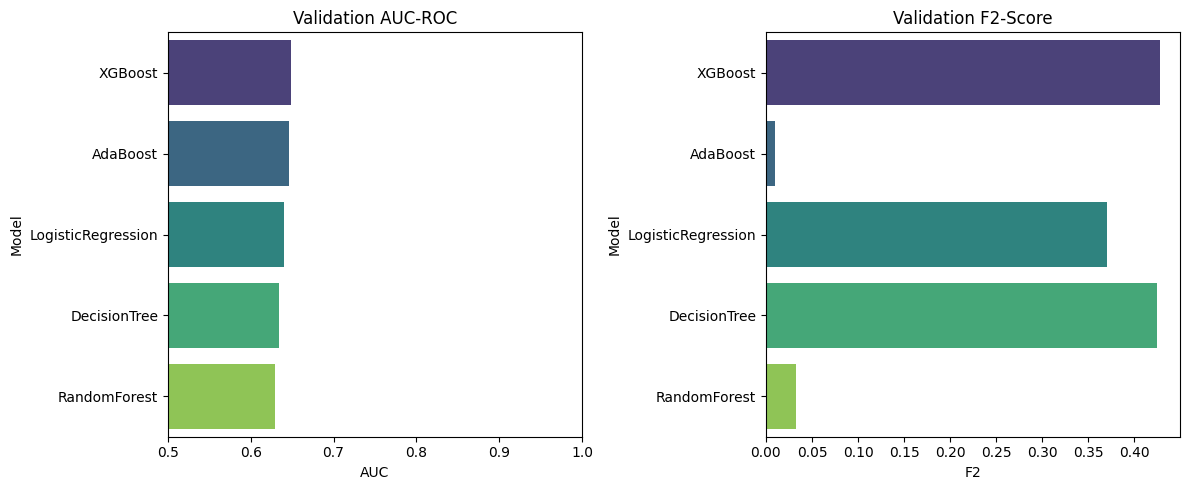

In [6]:
# plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=results_df, x='AUC', y='Model', palette='viridis')
plt.title('Validation AUC-ROC')
plt.xlim(0.5, 1.0)

plt.subplot(1, 2, 2)
sns.barplot(data=results_df, x='F2', y='Model', palette='viridis')
plt.title('Validation F2-Score')

plt.tight_layout()
plt.show()

In [ ]:
# ROC curves for all models
plt.figure(figsize=(10, 8))

for name, model in models.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves on Validation Set')
plt.legend()
plt.show()

In [ ]:
# hyperparameter tuning with Optuna
# using validation set to pick best params

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }
    
    pipe = make_pipeline(XGBClassifier(**params))
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)

print(f"\nbest val AUC: {study.best_value:.4f}")
print(f"best params: {study.best_params}")

In [ ]:
print("\ntraining stacking ensemble...")

base_models = [
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('ada', AdaBoostClassifier(n_estimators=50, random_state=42))
]

meta = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta,
    cv=2,
    stack_method='predict_proba',
    n_jobs=1  # sequential, avoids parallel overhead
)

stack_pipe = make_pipeline(stack)
stack_pipe.fit(X_train, y_train)

y_pred = stack_pipe.predict(X_val)
y_prob = stack_pipe.predict_proba(X_val)[:, 1]

print(f"stacking AUC: {roc_auc_score(y_val, y_prob):.4f}")
print(f"stacking F1: {f1_score(y_val, y_pred):.4f}")
print(f"stacking F2: {fbeta_score(y_val, y_pred, beta=2):.4f}")

In [ ]:


X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

best_xgb = XGBClassifier(
    **study.best_params,
    scale_pos_weight=(y_trainval == 0).sum() / (y_trainval == 1).sum(),
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
for col in cat_features:
    X_trainval[col] = X_trainval[col].astype(str)
    X_test[col] = X_test[col].astype(str)

final_pipe = make_pipeline(best_xgb)
final_pipe.fit(X_trainval, y_trainval)

# test evaluation
y_pred = final_pipe.predict(X_test)
y_prob = final_pipe.predict_proba(X_test)[:, 1]

print("="*50)
print("FINAL TEST SET RESULTS")
print("="*50)
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1:       {f1_score(y_test, y_pred):.4f}")
print(f"F2:       {fbeta_score(y_test, y_pred, beta=2):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['On-time', 'Delayed']))

In [ ]:

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

cost_fn = 400 * 150  # 150 passengers avg
cost_fp = 50 * 150

total_cost = fn * cost_fn + fp * cost_fp
naive_cost = (fn + tp) * cost_fn  # if we just said everything is on-time
savings = naive_cost - total_cost
savings_pct = (savings / naive_cost) * 100

print(f"Confusion Matrix:\n{cm}")
print(f"\nBusiness impact (150 pax/flight):")
print(f"Missed delays (FN): {fn}")
print(f"False alarms (FP): {fp}")
print(f"Model cost: ${total_cost:,.0f}")
print(f"Naive cost (all on-time): ${naive_cost:,.0f}")
print(f"Potential savings: ${savings:,.0f} ({savings_pct:.1f}%)")

In [ ]:
# save the pipeline for FastAPI deployment later
joblib.dump(final_pipe, '../app/flight_delay_pipeline.pkl')
print("saved pipeline to ../app/flight_delay_pipeline.pkl")